Loading IMDB movie review dataset...
Training set shape: 25000 reviews
Test set shape: 25000 reviews
Length of the first review: 218 words
Labels: {0, 1} (0=negative, 1=positive)
Padded training set shape: (25000, 500)
Padded test set shape: (25000, 500)

Federated Learning Experiment on IMDB Sentiment Analysis
Three-way Comparison: FedDAAW vs FedAvg vs FedProx
Using Fixed Client Ratios

Partitioning IMDB data with fixed ratios...

Client sample count allocation:
  Client 0: 5000 samples (20.0%)
  Client 1: 5000 samples (20.0%)
  Client 2: 2500 samples (10.0%)
  Client 3: 3750 samples (15.0%)
  Client 4: 5000 samples (20.0%)
  Client 5: 250 samples (1.0%)
  Client 6: 1250 samples (5.0%)
  Client 7: 125 samples (0.5%)
  Client 8: 125 samples (0.5%)
  Client 9: 2000 samples (8.0%)
Client 0: 5000 samples (negative: 2437, positive: 2563)
Client 1: 5000 samples (negative: 2528, positive: 2472)
Client 2: 2500 samples (negative: 1256, positive: 1244)
Client 3: 3750 samples (negative: 1859, po


[FedAvg Method]
Selected clients: [7, 5]

[FedProx Method]
Selected clients: [6, 2]

Round 20 results:
  FedDAAW Accuracy: 0.8637
  FedAvg Accuracy: 0.8506
  FedProx Accuracy: 0.4998

Global Round 21/23

[FedDAAW Method]
Selected clients: [4, 8]

[FedAvg Method]
Selected clients: [9, 7]

[FedProx Method]
Selected clients: [8, 5]

Round 21 results:
  FedDAAW Accuracy: 0.8729
  FedAvg Accuracy: 0.8567
  FedProx Accuracy: 0.5115

Global Round 22/23

[FedDAAW Method]
Selected clients: [2, 4]

[FedAvg Method]
Selected clients: [2, 4]

[FedProx Method]
Selected clients: [5, 9]

Round 22 results:
  FedDAAW Accuracy: 0.8673
  FedAvg Accuracy: 0.8622
  FedProx Accuracy: 0.4933

Global Round 23/23

[FedDAAW Method]
Selected clients: [0, 4]

[FedAvg Method]
Selected clients: [1, 0]

[FedProx Method]
Selected clients: [9, 0]

Round 23 results:
  FedDAAW Accuracy: 0.8742
  FedAvg Accuracy: 0.8604
  FedProx Accuracy: 0.5000


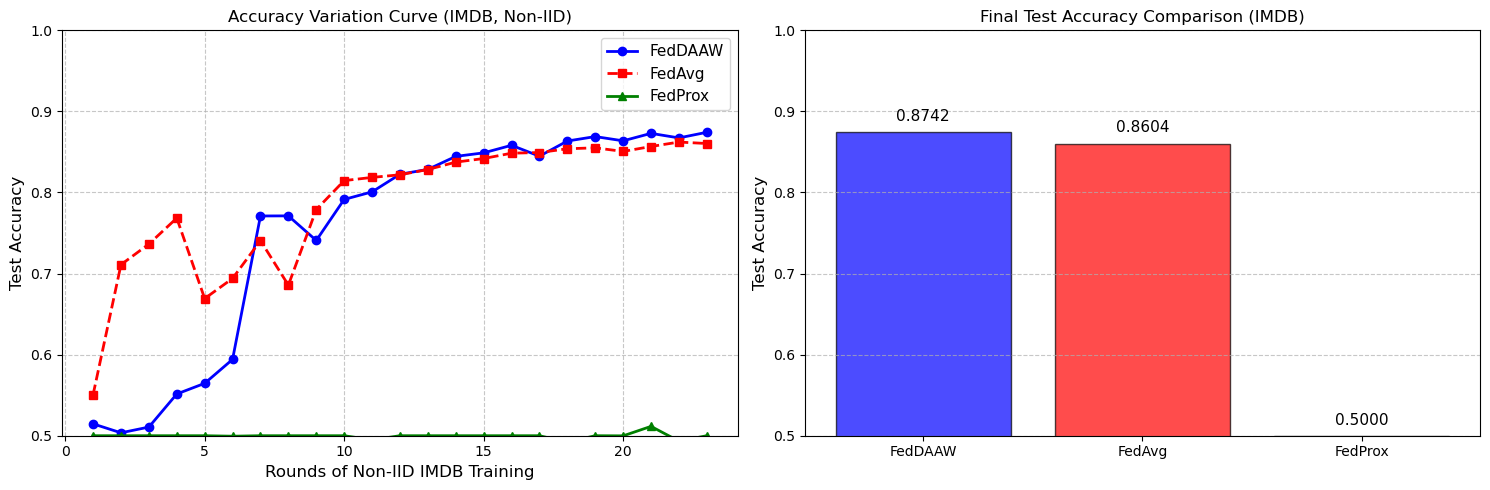


Final Experimental Results (Three-way Comparison on IMDB)
FedDAAW Final Accuracy: 0.8742
FedAvg Final Accuracy: 0.8604
FedProx Final Accuracy: 0.5000

----------------------------------------
Improvement Analysis:
FedDAAW vs FedAvg: +0.0138 (1.38%)
FedDAAW vs FedProx: +0.3742 (37.42%)


In [1]:
"""
Federated Learning Comparison: FedDAAW vs FedAvg vs FedProx
Dataset: IMDB Sentiment Analysis (Non-IID distribution)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Embedding, Flatten, GlobalAveragePooling1D, LSTM
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. 全局参数配置
# ============================================================

# Total number of clients participating in training in the federated learning system (10 devices/users in total)
NUM_CLIENTS = 10
# Number of dataset classes (IMDB has 2 classes: positive/negative)
NUM_CLASSES = 2

# Vocabulary size (only retain the most common words)
VOCAB_SIZE = 10000
# Maximum sequence length (truncate or pad to fixed length)
MAX_SEQUENCE_LENGTH = 500
# Embedding vector dimension
EMBEDDING_DIM = 16
# Size of time window for calculating client historical performance trends
WINDOW_SIZE = 5
# Weight of "historical performance trend" in client selection score
WEIGHT_HISTORY = 0.6
# Weight of "data quality (similarity with global model)" in client selection score
WEIGHT_DATA = 0.3

# Weight of "system status" in client selection score
WEIGHT_SYS = 0.1

# Number of clients selected from all clients to participate in training per federated learning round (select 2 out of 10)
NUM_SELECT_CLIENTS = 2

# Coefficient for smoothing current accuracy and historical average accuracy during adaptive aggregation
LAMBDA_SMOOTH = 0.9

# Number of training epochs executed locally by each selected client
LOCAL_EPOCHS = 1  # Reduce epochs because text data training is slower

# Learning rate
LEARNING_RATE = 0.001  # Text tasks usually require smaller learning rates

# Number of samples processed per batch during local training
BATCH_SIZE = 40

# Total number of communication rounds executed by the global coordinator (server)
NUM_GLOBAL_EPOCHS = 23  # Reduce global rounds

# ========== FedProx Proximal Term Coefficient ==========
# Controls the strength of the proximal term: mu/2 * ||w - w_global||²
# Recommended range: 0.001 ~ 0.1
FEDPROX_MU = 0.01

# Set random seed to ensure experimental reproducibility
tf.random.set_seed(42)
np.random.seed(42)
# Fixed client sample ratios
FIXED_RATIOS = [0.2, 0.2, 0.1, 0.15, 0.2, 0.01, 0.05, 0.005, 0.005, 0.08]


# ============================================================
# 2. 加载 IMDB 数据
# ============================================================

print("Loading IMDB movie review dataset...")

# Load IMDB dataset, retaining only the top 10000 most frequent words
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f"Training set shape: {len(x_train)} reviews")
print(f"Test set shape: {len(x_test)} reviews")
print(f"Length of the first review: {len(x_train[0])} words")
print(f"Labels: {set(y_train)} (0=negative, 1=positive)")

# Pad/truncate sequences to the same length
x_train = pad_sequences(x_train, maxlen=MAX_SEQUENCE_LENGTH)
x_test = pad_sequences(x_test, maxlen=MAX_SEQUENCE_LENGTH)

print(f"Padded training set shape: {x_train.shape}")
print(f"Padded test set shape: {x_test.shape}")

# Save original data for partitioning
x_train_original = x_train
y_train_original = y_train


# ============================================================
# 3. 工具函数
# ============================================================

def normalize_scores(scores):
    """Normalize scores to the range [0, 1]"""
    if len(scores) == 0:
        return np.array([])
    min_score = np.min(scores)
    max_score = np.max(scores)
    if max_score - min_score < 1e-6:
        return np.ones_like(scores) / len(scores)
    return (scores - min_score) / (max_score - min_score)


def build_model():
    """Build text classification model"""
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        GlobalAveragePooling1D(),
        Dense(16, activation='relu'),  # Reduce number of neurons
        Dropout(0.3),  # Reduce dropout rate
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# ============================================================
# 4. Non-IID 数据划分
# ============================================================

def load_and_partition_imdb_with_fixed_ratios(num_clients=10, fixed_ratios=None, val_ratio=0.3):
    """
    Partition IMDB dataset using fixed ratios
    Ensure each client has sufficient data
    """
    x_data = x_train_original
    y_data = y_train_original
    total_samples = len(x_data)
    
    # Normalize fixed ratios
    if fixed_ratios is None:
        fixed_ratios = [1.0 / num_clients] * num_clients
    else:
        ratios_sum = sum(fixed_ratios)
        fixed_ratios = [r / ratios_sum for r in fixed_ratios]
    
    # Calculate sample count for each client (ensure minimum sample count)
    client_sizes = []
    min_samples_per_client = 50  # Minimum samples per client
    
    for i, ratio in enumerate(fixed_ratios):
        size = max(min_samples_per_client, int(ratio * total_samples))
        client_sizes.append(size)
    
    # Adjust sample counts
    total_allocated = sum(client_sizes)
    if total_allocated > total_samples:
        # Scale down proportionally
        scale = total_samples / total_allocated
        client_sizes = [max(min_samples_per_client, int(size * scale)) for size in client_sizes]
    
    # Recalculate total allocation
    total_allocated = sum(client_sizes)
    diff = total_samples - total_allocated
    
    if diff != 0:
        # Distribute the difference to clients with more samples
        sorted_indices = np.argsort(client_sizes)[::-1]  # Sort from largest to smallest
        for i in range(abs(diff)):
            idx = sorted_indices[i % len(sorted_indices)]
            if diff > 0:
                client_sizes[idx] += 1
            else:
                client_sizes[idx] = max(min_samples_per_client, client_sizes[idx] - 1)
    
    print(f"\nClient sample count allocation:")
    for i, size in enumerate(client_sizes):
        print(f"  Client {i}: {size} samples ({size/total_samples*100:.1f}%)")
    
    # Allocate data
    client_data = []
    indices = np.random.permutation(total_samples)
    start_idx = 0
    
    for client_id in range(num_clients):
        target_size = client_sizes[client_id]
        end_idx = start_idx + target_size
        
        if end_idx > total_samples:
            # Reuse samples cyclically
            selected_indices = np.concatenate([indices[start_idx:], indices[:end_idx-total_samples]])
        else:
            selected_indices = indices[start_idx:end_idx]
        
        start_idx = end_idx % total_samples
        
        # Prepare client data
        X_client = x_data[selected_indices]
        y_client = y_data[selected_indices]
        
        # Split into training/validation sets
        split_idx = int(len(X_client) * (1 - val_ratio))
        
        client_dict = {
            'X_train': X_client[:split_idx],
            'y_train': y_client[:split_idx],
            'X_val': X_client[split_idx:],
            'y_val': y_client[split_idx:],
            'size': len(X_client)
        }
        
        client_data.append(client_dict)
        
        num_positive = np.sum(y_client)
        num_negative = len(y_client) - num_positive
        print(f"Client {client_id}: {len(X_client)} samples (negative: {num_negative}, positive: {num_positive})")
    
    return client_data


# ============================================================
# 5. 基础客户端类 (用于 FedAvg 和 FedDAAW)
# ============================================================

class Client:
    def __init__(self, client_id, data_dict):
        self.client_id = client_id
        self.X_train = data_dict['X_train']
        self.y_train = data_dict['y_train']
        self.X_val = data_dict['X_val']
        self.y_val = data_dict['y_val']
        self.model = build_model()
        self.acc_history = []
        self.acc_trend = 0.0
        self.data_similarity = 0.5
        self.sys_score = np.random.uniform(0.7, 1.0)
        self._model_weights = self.model.get_weights()  # Save current weights
        
    def local_train(self, global_weights):
        """Perform local training using global weights"""
        try:
            # Check if global weights are valid
            if global_weights is None or len(global_weights) == 0:
                print(f"Client {self.client_id}: Received empty global weights, using current model weights")
                global_weights = self._model_weights
            
            # Check if weight dimensions match
            if len(global_weights) != len(self.model.get_weights()):
                print(f"Client {self.client_id}: Weight dimensions do not match, using current model weights")
                global_weights = self._model_weights
            
            # Set weights
            self.model.set_weights(global_weights)
            
            # Check if there is training data
            if len(self.X_train) == 0:
                print(f"Client {self.client_id}: No training data available, returning original weights")
                return global_weights
            
            # Train model
            batch_size = min(BATCH_SIZE, len(self.X_train))
            
            # Use fewer epochs and simpler training
            history = self.model.fit(
                self.X_train, 
                self.y_train,
                epochs=LOCAL_EPOCHS, 
                batch_size=batch_size, 
                verbose=0,
                validation_split=0.1
            )
            
            # Get updated weights
            new_weights = self.model.get_weights()
            self._model_weights = new_weights  # Update saved weights
            
            # Validate weights
            if new_weights is None or len(new_weights) == 0:
                print(f"Client {self.client_id}: Weights are empty after training, returning original weights")
                return global_weights
            
            return new_weights
            
        except Exception as e:
            print(f"Client {self.client_id} training failed: {str(e)[:100]}...")
            # Return original weights as fallback
            return self._model_weights if self._model_weights is not None else global_weights
    
    def local_evaluate(self):
        """Evaluate model on local validation set"""
        try:
            if len(self.X_val) == 0:
                return 0.0
            
            # Use smaller batch size for prediction
            y_pred_probs = []
            batch_size = min(32, len(self.X_val))
            
            for i in range(0, len(self.X_val), batch_size):
                batch = self.X_val[i:i+batch_size]
                batch_pred = self.model.predict(batch, verbose=0)
                y_pred_probs.extend(batch_pred.flatten())
            
            y_pred = (np.array(y_pred_probs) > 0.5).astype(int)
            acc = accuracy_score(self.y_val, y_pred)
            
            # Update history
            self.acc_history.append(acc)
            
            # Calculate trend
            if len(self.acc_history) >= WINDOW_SIZE:
                x = np.arange(WINDOW_SIZE)
                slope, _, _, _, _ = stats.linregress(x, self.acc_history[-WINDOW_SIZE:])
                self.acc_trend = slope
            elif len(self.acc_history) >= 2:
                x = np.arange(len(self.acc_history))
                slope, _, _, _, _ = stats.linregress(x, self.acc_history)
                self.acc_trend = slope
            
            return acc
            
        except Exception as e:
            print(f"Client {self.client_id} evaluation failed: {str(e)[:100]}...")
            return 0.0
    
    def get_historical_performance_factor(self):
        return max(0, self.acc_trend) + 0.1
    
    def get_data_quality_factor(self):
        return max(0.1, min(1.0, self.data_similarity))
    
    def get_system_factor(self):
        return self.sys_score


# ============================================================
# 6. FedProx 客户端类 (带近端项)
# ============================================================

class FedProxClient(Client):
    """
    FedProx Client: Adds a proximal term to the local training loss
    Proximal term: mu/2 * ||w - w_global||²
    """
    def __init__(self, client_id, data_dict, mu=0.01):
        super().__init__(client_id, data_dict)
        self.mu = mu
        self.global_weights = None
    
    def local_train(self, global_weights):
        """
        Perform local training with FedProx proximal term
        Total loss = original_loss + (mu/2) * ||w - w_global||²
        """
        try:
            # Check if global weights are valid
            if global_weights is None or len(global_weights) == 0:
                print(f"FedProx Client {self.client_id}: Received empty global weights, using current model weights")
                global_weights = self._model_weights
            
            if len(global_weights) != len(self.model.get_weights()):
                print(f"FedProx Client {self.client_id}: Weight dimensions do not match, using current model weights")
                global_weights = self._model_weights
            
            # Save global weights for proximal term
            self.global_weights = [w.copy() for w in global_weights]
            self.model.set_weights(global_weights)
            
            if len(self.X_train) == 0:
                print(f"FedProx Client {self.client_id}: No training data available, returning original weights")
                return global_weights
            
            # Use Adam optimizer
            optimizer = Adam(learning_rate=LEARNING_RATE)
            
            train_dataset = tf.data.Dataset.from_tensor_slices((self.X_train, self.y_train))
            train_dataset = train_dataset.shuffle(buffer_size=len(self.X_train)).batch(BATCH_SIZE)
            
            for epoch in range(LOCAL_EPOCHS):
                for batch_x, batch_y in train_dataset:
                    with tf.GradientTape() as tape:
                        predictions = self.model(batch_x, training=True)
                        loss = tf.keras.losses.binary_crossentropy(batch_y, predictions)
                        loss = tf.reduce_mean(loss)
                        
                        # FedProx proximal term: (mu/2) * ||w - w_global||²
                        proximal_loss = 0.0
                        for local_w, global_w in zip(self.model.trainable_weights, self.global_weights):
                            proximal_loss += tf.reduce_sum(tf.square(local_w - global_w))
                        proximal_loss = (self.mu / 2.0) * proximal_loss
                        
                        total_loss = loss + proximal_loss
                    
                    grads = tape.gradient(total_loss, self.model.trainable_weights)
                    optimizer.apply_gradients(zip(grads, self.model.trainable_weights))
            
            new_weights = self.model.get_weights()
            self._model_weights = new_weights
            return new_weights
            
        except Exception as e:
            print(f"FedProx Client {self.client_id} training failed: {str(e)[:100]}...")
            return self._model_weights if self._model_weights is not None else global_weights


# ============================================================
# 7. 服务器: FedDAAW
# ============================================================

class ServerDA:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []
    
    def calculate_selection_score(self, clients):
        """Calculate client selection score"""
        scores = []
        for c in clients:
            hist_factor = c.get_historical_performance_factor()
            data_factor = c.get_data_quality_factor()
            sys_factor = c.get_system_factor()
            
            score = (WEIGHT_HISTORY * hist_factor + 
                    WEIGHT_DATA * data_factor + 
                    WEIGHT_SYS * sys_factor)
            scores.append(score)
        
        return np.array(scores)
    
    def select_clients(self, clients):
        """Select clients"""
        scores = self.calculate_selection_score(clients)
        probs = normalize_scores(scores)
        
        if len(probs) == 0 or np.all(probs == 0):
            probs = np.ones(len(clients)) / len(clients)
        else:
            probs = probs / probs.sum()
        
        indices = np.random.choice(
            len(clients), 
            size=min(NUM_SELECT_CLIENTS, len(clients)), 
            replace=False, 
            p=probs
        )
        
        selected = [clients[i] for i in indices]
        return selected
    
    def calculate_adaptive_weights(self, selected_clients):
        """Calculate adaptive aggregation weights"""
        weights = []
        for c in selected_clients:
            if len(c.acc_history) == 0:
                weights.append(1.0)  # Default weight
            else:
                current = c.acc_history[-1] if c.acc_history else 0.5
                avg = np.mean(c.acc_history) if len(c.acc_history) > 0 else current
                smoothed = LAMBDA_SMOOTH * current + (1 - LAMBDA_SMOOTH) * avg
                weights.append(smoothed)
        
        weights = np.array(weights)
        if np.sum(weights) > 0:
            weights = weights / np.sum(weights)
        else:
            weights = np.ones(len(weights)) / len(weights)
        
        return weights
    
    def aggregate(self, selected_clients, client_weights_list):
        """Aggregate client models"""
        if len(selected_clients) == 0:
            print("No clients selected, skipping aggregation")
            return
        
        # Filter valid weights
        valid_weights = []
        valid_clients = []
        
        for i, (client, weights) in enumerate(zip(selected_clients, client_weights_list)):
            if weights is not None and len(weights) > 0 and len(weights) == len(self.global_weights):
                valid_weights.append(weights)
                valid_clients.append(client)
            else:
                print(f"Client {client.client_id} has invalid weights, skipping")
        
        if len(valid_weights) == 0:
            print("All client weights are invalid, skipping aggregation")
            return
        
        # Calculate aggregation weights
        adaptive_w = self.calculate_adaptive_weights(valid_clients)
        
        # Aggregate weights
        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            weighted_sum = np.zeros_like(self.global_weights[layer_idx])
            for alpha, cw in zip(adaptive_w, valid_weights):
                weighted_sum += alpha * cw[layer_idx]
            new_weights.append(weighted_sum)
        
        self.global_weights = new_weights
        self.global_model.set_weights(self.global_weights)
    
    def evaluate(self):
        """Evaluate global model on test set"""
        try:
            # Ensure weights are valid
            if self.global_weights is None or len(self.global_weights) == 0:
                print("Global weights are empty, using initial weights")
                self.global_weights = self.global_model.get_weights()
            
            self.global_model.set_weights(self.global_weights)
            
            # Batch prediction
            predictions = []
            batch_size = 500
            
            for i in range(0, len(x_test), batch_size):
                batch = x_test[i:i+batch_size]
                batch_pred = self.global_model.predict(batch, verbose=0)
                predictions.append(batch_pred)
            
            y_pred_probs = np.vstack(predictions)
            y_pred = (y_pred_probs > 0.5).astype(int).flatten()
            
            acc = accuracy_score(y_test, y_pred)
            self.global_acc_history.append(acc)
            
            return acc
            
        except Exception as e:
            print(f"Global evaluation failed: {str(e)[:100]}...")
            return 0.5  # Return random accuracy


# ============================================================
# 8. 服务器: FedAvg (基线)
# ============================================================

class ServerFedAvg:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []
    
    def select_clients(self, clients):
        """Randomly select clients"""
        indices = np.random.choice(
            len(clients), 
            size=min(NUM_SELECT_CLIENTS, len(clients)), 
            replace=False
        )
        return [clients[i] for i in indices]
    
    def aggregate(self, client_weights_list):
        """FedAvg aggregation"""
        if len(client_weights_list) == 0:
            print("Client weights list is empty, skipping aggregation")
            return
        
        # Filter valid weights
        valid_weights = []
        for weights in client_weights_list:
            if weights is not None and len(weights) > 0 and len(weights) == len(self.global_weights):
                valid_weights.append(weights)
        
        if len(valid_weights) == 0:
            print("All client weights are invalid, skipping aggregation")
            return
        
        # Simple average
        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in valid_weights:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(valid_weights)
            new_weights.append(avg_layer)
        
        self.global_weights = new_weights
        self.global_model.set_weights(self.global_weights)
    
    def evaluate(self):
        """Evaluate global model on test set"""
        try:
            # Ensure weights are valid
            if self.global_weights is None or len(self.global_weights) == 0:
                print("Global weights are empty, using initial weights")
                self.global_weights = self.global_model.get_weights()
            
            self.global_model.set_weights(self.global_weights)
            
            # Batch prediction
            predictions = []
            batch_size = 500
            
            for i in range(0, len(x_test), batch_size):
                batch = x_test[i:i+batch_size]
                batch_pred = self.global_model.predict(batch, verbose=0)
                predictions.append(batch_pred)
            
            y_pred_probs = np.vstack(predictions)
            y_pred = (y_pred_probs > 0.5).astype(int).flatten()
            
            acc = accuracy_score(y_test, y_pred)
            self.global_acc_history.append(acc)
            
            return acc
            
        except Exception as e:
            print(f"Global evaluation failed: {str(e)[:100]}...")
            return 0.5


# ============================================================
# 9. 服务器: FedProx
# ============================================================

class ServerFedProx:
    def __init__(self):
        self.global_model = build_model()
        self.global_weights = self.global_model.get_weights()
        self.global_acc_history = []
    
    def select_clients(self, clients):
        """Randomly select clients (same as FedAvg)"""
        indices = np.random.choice(
            len(clients), 
            size=min(NUM_SELECT_CLIENTS, len(clients)), 
            replace=False
        )
        return [clients[i] for i in indices]
    
    def aggregate(self, client_weights_list):
        """FedProx aggregation: simple average (same as FedAvg)"""
        if len(client_weights_list) == 0:
            print("Client weights list is empty, skipping aggregation")
            return
        
        # Filter valid weights
        valid_weights = []
        for weights in client_weights_list:
            if weights is not None and len(weights) > 0 and len(weights) == len(self.global_weights):
                valid_weights.append(weights)
        
        if len(valid_weights) == 0:
            print("All client weights are invalid, skipping aggregation")
            return
        
        # Simple average
        new_weights = []
        for layer_idx in range(len(self.global_weights)):
            avg_layer = np.zeros_like(self.global_weights[layer_idx])
            for cw in valid_weights:
                avg_layer += cw[layer_idx]
            avg_layer = avg_layer / len(valid_weights)
            new_weights.append(avg_layer)
        
        self.global_weights = new_weights
        self.global_model.set_weights(self.global_weights)
    
    def evaluate(self):
        """Evaluate global model on test set"""
        try:
            # Ensure weights are valid
            if self.global_weights is None or len(self.global_weights) == 0:
                print("Global weights are empty, using initial weights")
                self.global_weights = self.global_model.get_weights()
            
            self.global_model.set_weights(self.global_weights)
            
            # Batch prediction
            predictions = []
            batch_size = 500
            
            for i in range(0, len(x_test), batch_size):
                batch = x_test[i:i+batch_size]
                batch_pred = self.global_model.predict(batch, verbose=0)
                predictions.append(batch_pred)
            
            y_pred_probs = np.vstack(predictions)
            y_pred = (y_pred_probs > 0.5).astype(int).flatten()
            
            acc = accuracy_score(y_test, y_pred)
            self.global_acc_history.append(acc)
            
            return acc
            
        except Exception as e:
            print(f"Global evaluation failed: {str(e)[:100]}...")
            return 0.5


# ============================================================
# 10. 主训练函数 (三路对比)
# ============================================================

da_accuracies = []
fedavg_accuracies = []
fedprox_accuracies = []


def main():
    global da_accuracies, fedavg_accuracies, fedprox_accuracies
    
    print("\n" + "="*60)
    print("Federated Learning Experiment on IMDB Sentiment Analysis")
    print("Three-way Comparison: FedDAAW vs FedAvg vs FedProx")
    print("Using Fixed Client Ratios")
    print("="*60)
    
    # Partition IMDB data with fixed ratios
    print("\nPartitioning IMDB data with fixed ratios...")
    client_datasets = load_and_partition_imdb_with_fixed_ratios(
        num_clients=NUM_CLIENTS, 
        fixed_ratios=FIXED_RATIOS,
        val_ratio=0.2
    )
    
    # Create three groups of clients (same data, independent models)
    clients_da = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedavg = [Client(i, client_datasets[i]) for i in range(NUM_CLIENTS)]
    clients_fedprox = [FedProxClient(i, client_datasets[i], mu=FEDPROX_MU) for i in range(NUM_CLIENTS)]
    
    # Initialize servers
    server_da = ServerDA()
    server_fedavg = ServerFedAvg()
    server_fedprox = ServerFedProx()
    
    print(f"\nStarting federated learning training...")
    print(f"Global epochs: {NUM_GLOBAL_EPOCHS}")
    print(f"Clients selected per round: {NUM_SELECT_CLIENTS}")
    print(f"Local training epochs: {LOCAL_EPOCHS}")
    print(f"FedProx mu: {FEDPROX_MU}")
    
    for epoch in range(NUM_GLOBAL_EPOCHS):
        print(f"\n{'='*50}")
        print(f"Global Round {epoch+1}/{NUM_GLOBAL_EPOCHS}")
        print(f"{'='*50}")
        
        # ========== 1. FedDAAW ==========
        print("\n[FedDAAW Method]")
        selected_da = server_da.select_clients(clients_da)
        print(f"Selected clients: {[c.client_id for c in selected_da]}")
        
        weights_da = []
        for client in selected_da:
            weights = client.local_train(server_da.global_weights)
            weights_da.append(weights)
        
        for client in selected_da:
            client.local_evaluate()
        
        server_da.aggregate(selected_da, weights_da)
        acc_da = server_da.evaluate()
        da_accuracies.append(acc_da)
        
        # ========== 2. FedAvg ==========
        print("\n[FedAvg Method]")
        selected_fed = server_fedavg.select_clients(clients_fedavg)
        print(f"Selected clients: {[c.client_id for c in selected_fed]}")
        
        weights_fed = []
        for client in selected_fed:
            weights = client.local_train(server_fedavg.global_weights)
            weights_fed.append(weights)
        
        for client in selected_fed:
            client.local_evaluate()
        
        server_fedavg.aggregate(weights_fed)
        acc_fed = server_fedavg.evaluate()
        fedavg_accuracies.append(acc_fed)
        
        # ========== 3. FedProx ==========
        print("\n[FedProx Method]")
        selected_prox = server_fedprox.select_clients(clients_fedprox)
        print(f"Selected clients: {[c.client_id for c in selected_prox]}")
        
        weights_prox = []
        for client in selected_prox:
            weights = client.local_train(server_fedprox.global_weights)
            weights_prox.append(weights)
        
        for client in selected_prox:
            client.local_evaluate()
        
        server_fedprox.aggregate(weights_prox)
        acc_prox = server_fedprox.evaluate()
        fedprox_accuracies.append(acc_prox)
        
        print(f"\nRound {epoch+1} results:")
        print(f"  FedDAAW Accuracy: {acc_da:.4f}")
        print(f"  FedAvg Accuracy: {acc_fed:.4f}")
        print(f"  FedProx Accuracy: {acc_prox:.4f}")


# ============================================================
# 11. 可视化与结果输出
# ============================================================

def plot_results():
    """Plot three-way comparison results"""
    epochs_trained = len(da_accuracies)
    
    if epochs_trained == 0:
        print("No training data available. Please run main() first.")
        return
    
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: Accuracy curves
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_trained + 1), da_accuracies, 'b-o', linewidth=2, markersize=6, label='FedDAAW')
    plt.plot(range(1, epochs_trained + 1), fedavg_accuracies, 'r--s', linewidth=2, markersize=6, label='FedAvg')
    plt.plot(range(1, epochs_trained + 1), fedprox_accuracies, 'g-^', linewidth=2, markersize=6, label='FedProx')
    plt.xlabel('Rounds of Non-IID IMDB Training', fontsize=12)
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Accuracy Variation Curve (IMDB, Non-IID)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim([0.5, 1.0])
    
    # Subplot 2: Final accuracy comparison
    plt.subplot(1, 2, 2)
    methods = ['FedDAAW', 'FedAvg', 'FedProx']
    final_accs = [da_accuracies[-1], fedavg_accuracies[-1], fedprox_accuracies[-1]]
    colors = ['blue', 'red', 'green']
    
    bars = plt.bar(methods, final_accs, color=colors, alpha=0.7, edgecolor='black')
    plt.ylabel('Test Accuracy', fontsize=12)
    plt.title('Final Test Accuracy Comparison (IMDB)', fontsize=12)
    plt.ylim([0.5, 1.0])
    
    # Display accuracy values on the bar chart
    for bar, acc in zip(bars, final_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
    
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # ---------- Print Final Results ----------
    print("\n" + "="*60)
    print("Final Experimental Results (Three-way Comparison on IMDB)")
    print("="*60)
    print(f"FedDAAW Final Accuracy: {da_accuracies[-1]:.4f}")
    print(f"FedAvg Final Accuracy: {fedavg_accuracies[-1]:.4f}")
    print(f"FedProx Final Accuracy: {fedprox_accuracies[-1]:.4f}")
    
    print("\n" + "-"*40)
    print("Improvement Analysis:")
    improvement_da_vs_avg = da_accuracies[-1] - fedavg_accuracies[-1]
    improvement_da_vs_prox = da_accuracies[-1] - fedprox_accuracies[-1]
    print(f"FedDAAW vs FedAvg: +{improvement_da_vs_avg:.4f} ({improvement_da_vs_avg*100:.2f}%)")
    print(f"FedDAAW vs FedProx: +{improvement_da_vs_prox:.4f} ({improvement_da_vs_prox*100:.2f}%)")


# ============================================================
# 12. 程序入口
# ============================================================

if __name__ == "__main__":
    main()
    plot_results()